# Optimization applied to a linear system

Original source code by [Rahul Halder](https://github.com/rahulhalderAERO/DisPINN3/tree/main)

In [7]:
import pickle as pkl
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

In [8]:
class LinearNN(nn.Module):
    def __init__(self, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden_size//2, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size//2, hidden_size, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size//2, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size//2, 1, bias=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

In [9]:
with open("outputs/opt_state/optimizer_results_weight_decay.pkl", "rb") as f:
    results = pkl.load(f)

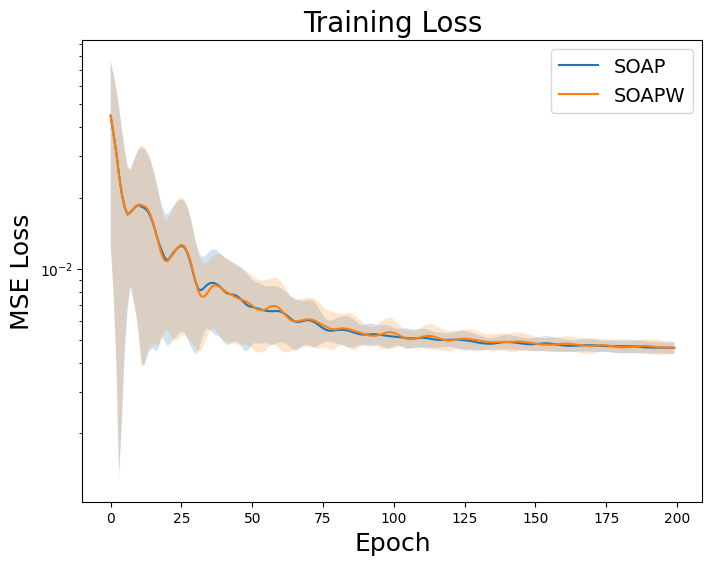

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for i, opt_name in enumerate(results):
    loss_avg = np.mean(results[opt_name]["loss_histories"], axis = 1)
    loss_std = np.std(results[opt_name]["loss_histories"], axis = 1)
    ax.plot(loss_avg, label=opt_name)
    ax.fill_between(range(len(loss_avg)),                    
                    loss_avg - loss_std,
                    loss_avg + loss_std, alpha=0.2)
ax.set_title("Training Loss", fontsize=20)
ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=18)
ax.set_ylabel("MSE Loss", fontsize=18)
ax.legend(fontsize=14)

plt.savefig("./outputs/plots/soap_preconditioning_frequency.png")